In this exercise, you will further analyze the Wage data set considered throughout this chapter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from ISLP import load_data
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [3]:
# 載入 Wage 資料集
Wage = load_data('Wage')
Wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


**(a)** Perform polynomial regression to predict `wage` using `age`. 
Use cross-validation to select the optimal degree $d$ for the polynomial. 
What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? 
Make a plot of the resulting polynomial fit to the data.

In [5]:
# Cross-Validation to select optimal degree
np.random.seed(1)
degrees = range(1, 11)  # Test degrees 1 to 10
cv_errors = []

# Prepare data
X = Wage[['age']]
y = Wage['wage']
cv = KFold(n_splits=10, shuffle=True, random_state=1)

print("Performing Cross-Validation...")
for d in degrees:
    # Create pipeline: Polynomial Features -> Linear Regression
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('lin_reg', LinearRegression())
    ])
    
    # Compute MSE using CV (neg_mean_squared_error returns negative values)
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=cv)
    cv_errors.append(-np.mean(scores))

# Find the degree with the minimum error
best_degree = degrees[np.argmin(cv_errors)]
print(f"\nOptimal degree selected by CV: {best_degree}")
print(f"CV MSE for degree {best_degree}: {min(cv_errors):.4f}")

Performing Cross-Validation...

Optimal degree selected by CV: 6
CV MSE for degree 6: 1594.7655


In [6]:
# Hypothesis Testing using ANOVA
models = []
print("\nFitting models for ANOVA...")
for d in range(1, 6):
    # Construct formula: wage ~ age + I(age**2) + ...
    poly_terms = " + ".join([f"np.power(age, {i})" for i in range(1, d+1)])
    formula = f"wage ~ {poly_terms}"
    
    model = smf.ols(formula, data=Wage).fit()
    models.append(model)

# Perform ANOVA comparing M1 vs M2, M2 vs M3, etc.
anova_results = sm.stats.anova_lm(*models, typ=1)
print("\nANOVA Results (M1 to M5):")
print(anova_results)


Fitting models for ANOVA...

ANOVA Results (M1 to M5):
   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


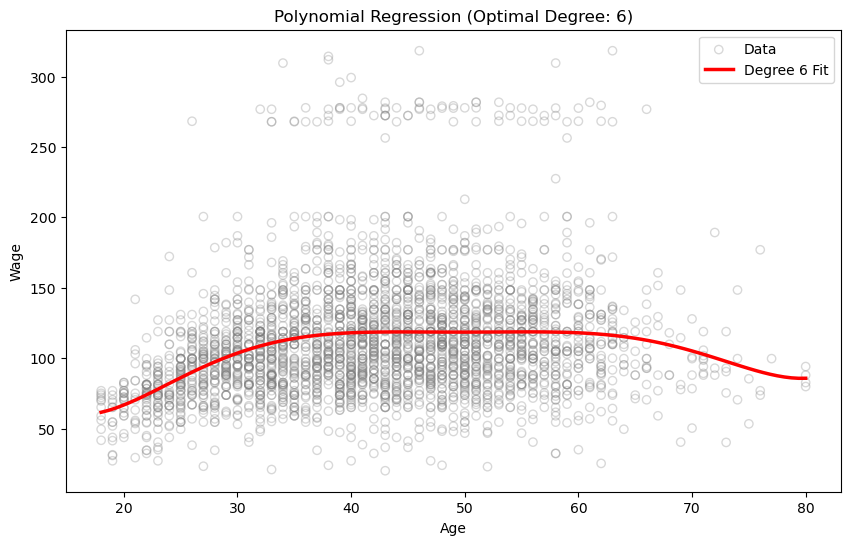

In [7]:
# Plotting the best fit
# Refit the best model on the full dataset
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('lin_reg', LinearRegression())
])
final_model.fit(X, y)

# Create a range of values for plotting
x_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = final_model.predict(x_grid)

plt.figure(figsize=(10, 6))
# Scatter plot of raw data
plt.scatter(Wage['age'], Wage['wage'], facecolor='None', edgecolor='gray', alpha=0.3, label='Data')
# Plot the polynomial fit
plt.plot(x_grid, y_pred, color='red', linewidth=2.5, label=f'Degree {best_degree} Fit')

plt.title(f'Polynomial Regression (Optimal Degree: {best_degree})')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.legend()
plt.show()

**(b)** Fit a step function to predict `wage` using `age`, and perform cross-validation to choose the optimal number of cuts. 
Make a plot of the fit obtained.

In [9]:
import warnings
warnings.filterwarnings('ignore')
#Cross-Validation to choose number of cuts
cuts_range = range(2, 11) # Try 2 to 10 cuts (bins)
cv_errors_step = []

print("Performing Cross-Validation for Step Function...")
for c in cuts_range:
    # Pipeline: Discretizer (Step Function) -> Linear Regression
    # strategy='uniform' means equal-width bins, 'quantile' means equal-count bins
    model_step = Pipeline([
        ('discretizer', KBinsDiscretizer(n_bins=c, encode='onehot', strategy='uniform')),
        ('lin_reg', LinearRegression())
    ])
    
    scores = cross_val_score(model_step, X, y, scoring='neg_mean_squared_error', cv=cv)
    cv_errors_step.append(-np.mean(scores))

# Find optimal cuts
best_cuts = cuts_range[np.argmin(cv_errors_step)]
print(f"\nOptimal number of cuts (bins): {best_cuts}")
print(f"CV MSE for {best_cuts} cuts: {min(cv_errors_step):.4f}")


Performing Cross-Validation for Step Function...

Optimal number of cuts (bins): 8
CV MSE for 8 cuts: 1602.1438


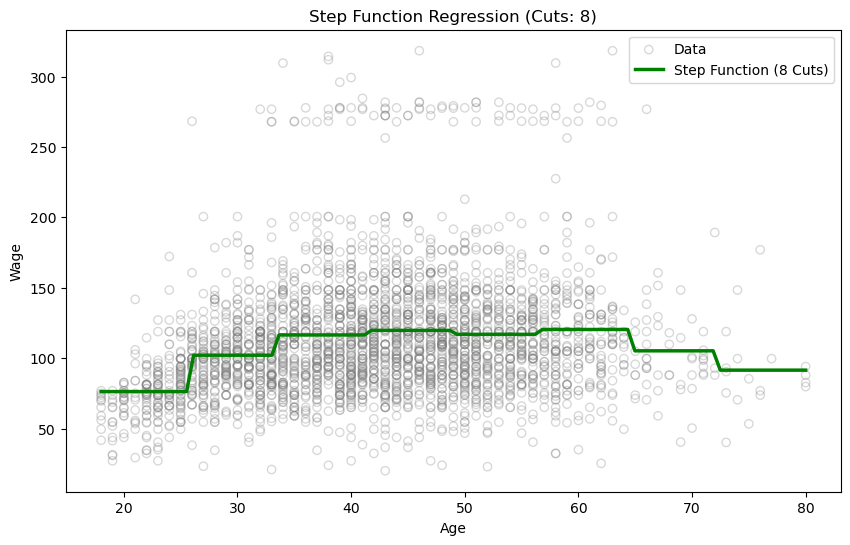

In [10]:
# Plotting the fit
# Refit best step model
final_step_model = Pipeline([
    ('discretizer', KBinsDiscretizer(n_bins=best_cuts, encode='onehot', strategy='uniform')),
    ('lin_reg', LinearRegression())
])
final_step_model.fit(X, y)

# Predict on grid
y_pred_step = final_step_model.predict(x_grid)

plt.figure(figsize=(10, 6))
plt.scatter(Wage['age'], Wage['wage'], facecolor='None', edgecolor='gray', alpha=0.3, label='Data')
plt.plot(x_grid, y_pred_step, color='green', linewidth=2.5, label=f'Step Function ({best_cuts} Cuts)')

plt.title(f'Step Function Regression (Cuts: {best_cuts})')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.legend()
plt.show()